In [12]:
import pandas as pd

df = pd.read_csv("symbols_valid_meta.csv")

print(df.head())
print(df.info())

  Nasdaq Traded Symbol                                      Security Name  \
0             Y      A            Agilent Technologies, Inc. Common Stock   
1             Y     AA                    Alcoa Corporation Common Stock    
2             Y   AAAU                       Perth Mint Physical Gold ETF   
3             Y   AACG  ATA Creativity Global - American Depositary Sh...   
4             Y   AADR                AdvisorShares Dorsey Wright ADR ETF   

  Listing Exchange Market Category ETF  Round Lot Size Test Issue  \
0                N                   N           100.0          N   
1                N                   N           100.0          N   
2                P                   Y           100.0          N   
3                Q               G   N           100.0          N   
4                P                   Y           100.0          N   

  Financial Status CQS Symbol NASDAQ Symbol NextShares  
0              NaN          A             A          N  
1       

In [13]:
print(df.isnull().sum())

Nasdaq Traded          0
Symbol                 0
Security Name          0
Listing Exchange       0
Market Category        0
ETF                    0
Round Lot Size         0
Test Issue             0
Financial Status    4666
CQS Symbol          3383
NASDAQ Symbol          0
NextShares             0
dtype: int64


In [14]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicates: 0


In [15]:
print(df.describe())

       Round Lot Size
count     8049.000000
mean        99.942974
std          2.289194
min          1.000000
25%        100.000000
50%        100.000000
75%        100.000000
max        100.000000


Q    3383
N    2520
P    1542
Z     351
A     253
Name: Listing Exchange, dtype: int64


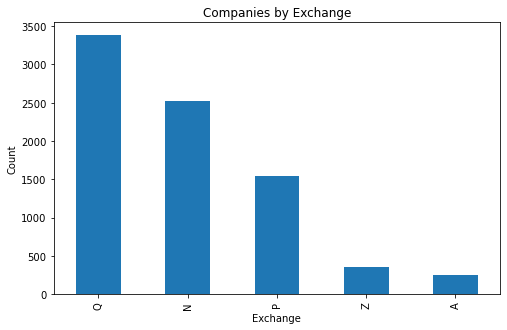

In [16]:
import matplotlib.pyplot as plt

exchange_counts = df['Listing Exchange'].value_counts()

print(exchange_counts)

plt.figure(figsize=(8,5))
exchange_counts.plot(kind='bar')

plt.title("Companies by Exchange")
plt.xlabel("Exchange")
plt.ylabel("Count")

plt.show()

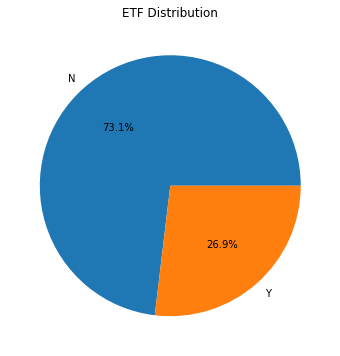

In [17]:
etf_counts = df['ETF'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    etf_counts,
    labels=etf_counts.index,
    autopct='%1.1f%%'
)

plt.title("ETF Distribution")

plt.show()

     4666
Q    1531
S     952
G     900
Name: Market Category, dtype: int64


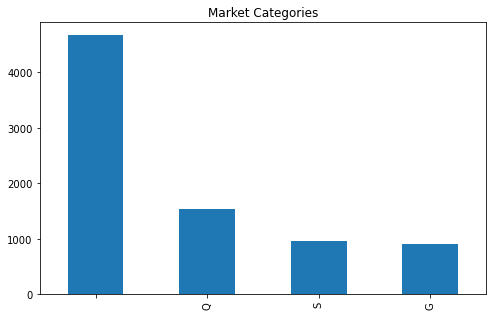

In [18]:
market_counts = df['Market Category'].value_counts()

print(market_counts)

plt.figure(figsize=(8,5))
market_counts.plot(kind='bar')

plt.title("Market Categories")

plt.show()

N    3180
D     191
E       8
H       4
Name: Financial Status, dtype: int64


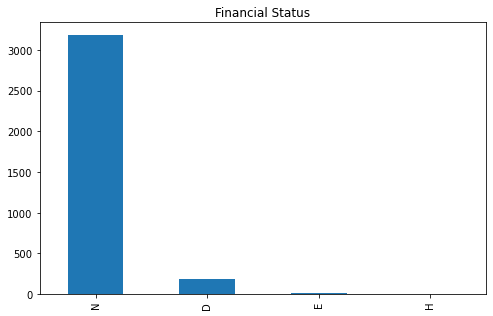

In [19]:
status_counts = df['Financial Status'].value_counts()

print(status_counts)

plt.figure(figsize=(8,5))
status_counts.plot(kind='bar')

plt.title("Financial Status")

plt.show()

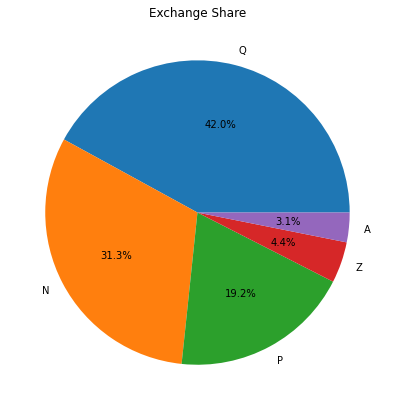

In [20]:
exchange_counts = df['Listing Exchange'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    exchange_counts,
    labels=exchange_counts.index,
    autopct='%1.1f%%'
)

plt.title("Exchange Share")

plt.show()

In [21]:
print(df['Round Lot Size'].describe())

count    8049.000000
mean       99.942974
std         2.289194
min         1.000000
25%       100.000000
50%       100.000000
75%       100.000000
max       100.000000
Name: Round Lot Size, dtype: float64


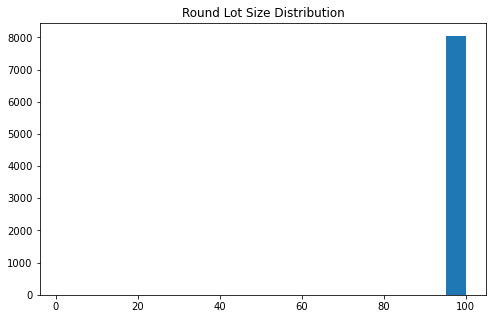

In [22]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Round Lot Size'],
    bins=20
)

plt.title("Round Lot Size Distribution")

plt.show()

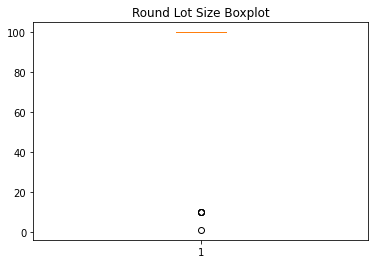

In [23]:
plt.figure(figsize=(6,4))

plt.boxplot(df['Round Lot Size'])

plt.title("Round Lot Size Boxplot")

plt.show()

In [24]:
Q1 = df['Round Lot Size'].quantile(0.25)

Q3 = df['Round Lot Size'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Round Lot Size'] < lower) |
    (df['Round Lot Size'] > upper)
]

print(outliers)

     Nasdaq Traded Symbol                               Security Name  \
743              Y     BH  Biglari Holdings Inc. Class B Common Stock   
1806             Y    DIT     AMCON Distributing Company Common Stock   
4662             Y    MKL             Markel Corporation Common Stock   
5169             Y    NVR                      NVR, Inc. Common Stock   
6406             Y    SEB           Seaboard Corporation Common Stock   

     Listing Exchange Market Category ETF  Round Lot Size Test Issue  \
743                 N                   N            10.0          N   
1806                A                   N            10.0          N   
4662                N                   N            10.0          N   
5169                N                   N            10.0          N   
6406                A                   N             1.0          N   

     Financial Status CQS Symbol NASDAQ Symbol NextShares  
743               NaN         BH            BH          N  
1806    

In [26]:
top_exchanges = df['Listing Exchange'].value_counts()

print(top_exchanges)

Q    3383
N    2520
P    1542
Z     351
A     253
Name: Listing Exchange, dtype: int64


In [27]:
etf_analysis = df.groupby('ETF').size()

print(etf_analysis)

ETF
N    5884
Y    2165
dtype: int64


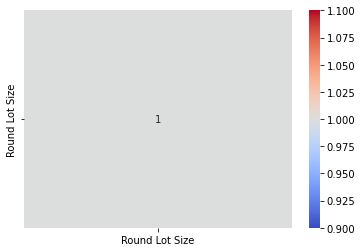

In [28]:
import seaborn as sns

corr = df[['Round Lot Size']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [29]:
df['Name Length'] = df['Security Name'].str.len()

top_names = df.nlargest(10, 'Name Length')

print(top_names[['Symbol', 'Security Name', 'Name Length']])

     Symbol                                      Security Name  Name Length
3011    GJP  Synthetic Fixed-Income Securities, Inc. Synthe...          254
2065    EEH  Aktiebolaget Svensk Exportkredit (Swed Ex Cred...          199
3546  IBKCN  IBERIABANK Corporation - Depositary Shares eac...          183
7202  TSCBP  TriState Capital Holdings, Inc. - Depositary S...          176
8021  ZIONO  Zions Bancorporation N.A. - Depositary Shares ...          175
3014    GJT  Synthetic Fixed-Income Securities, Inc. Synthe...          173
169   AGNCP  AGNC Investment Corp. - Depositary Shares Each...          171
167   AGNCN  AGNC Investment Corp. - Depositary Shares Each...          170
701    BDXA  Becton, Dickinson and Company Depositary Share...          170
8022  ZIONP  Zions Bancorporation N.A. - Depositary Shares ...          169


In [30]:
exchange_count = df.groupby('Listing Exchange').size()

print(exchange_count)

Listing Exchange
A     253
N    2520
P    1542
Q    3383
Z     351
dtype: int64


In [31]:
market = df['Market Category'].value_counts()

print(market)

     4666
Q    1531
S     952
G     900
Name: Market Category, dtype: int64
